In [17]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import imagehash
import os



In [18]:
# --- 1. SETTINGS ---
Image_size = 96
Batch = 32
Random_seed = 42

# --- 2. GLOBAL DEDUPLICATION (The "Honesty" Step) ---
def get_clean_data(dirs):
    all_paths, all_labels = [], []
    for d in dirs:
        # Assuming folder names are classes: 'No_Fire' and 'Fire'
        class_names = sorted(os.listdir(d))
        class_to_idx = {name: i for i, name in enumerate(class_names)}
        for class_name in class_names:
            c_path = os.path.join(d, class_name)
            if not os.path.isdir(c_path): continue
            files = [os.path.join(c_path, f) for f in os.listdir(c_path)]
            all_paths.extend(files)
            all_labels.extend([class_to_idx[class_name]] * len(files))
    
    # Use hashing to remove duplicates across ALL provided directories
    unique_hashes = {}
    clean_paths, clean_labels = [], []
    print(f"Total raw files: {len(all_paths)}")
    for p, l in zip(all_paths, all_labels):
        try:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
        except: continue
    print(f"Total unique files: {len(clean_paths)}")
    return clean_paths, clean_labels

# Process both folders to ensure the Test set doesn't contain Train images
all_p, all_l = get_clean_data(["Training_Bi/", "Test/"])

# --- 3. RE-SPLITTING (Stratified) ---
tr_p, temp_p, tr_l, temp_l = train_test_split(
    all_p, all_l, test_size=0.25, random_state=Random_seed, stratify=all_l
)
val_p, te_p, val_l, te_l = train_test_split(
    temp_p, temp_l, test_size=0.5, random_state=Random_seed, stratify=temp_l
)


Total raw files: 47992
Total unique files: 12691


In [19]:
# --- 4. DATA PIPELINE & ENHANCED AUGMENTATION ---
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [Image_size, Image_size])
    return img, label

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, 0.3)
    image = tf.image.random_contrast(image, 0.7, 1.4)
    
    # Haze Augmentation (from your ternary logic)
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7
    image = tf.cond(tf.random.uniform(()) > 0.5, 
                    lambda: image * (1 - haze_intensity) + haze * haze_intensity, 
                    lambda: image)
    
    return tf.clip_by_value(image, 0.0, 1.0), label

def normalize(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = (tf.data.Dataset.from_tensor_slices((tr_p, tr_l))
            .shuffle(len(tr_p)).map(load_and_preprocess).map(augment).batch(Batch).prefetch(2))
val_ds = (tf.data.Dataset.from_tensor_slices((val_p, val_l))
          .map(load_and_preprocess).map(normalize).batch(Batch).prefetch(2))
test_ds = (tf.data.Dataset.from_tensor_slices((te_p, te_l))
           .map(load_and_preprocess).map(normalize).batch(Batch).prefetch(2))

# --- 5. FOCAL LOSS & WEIGHTS ---
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha * tf.pow(1 - p_t, gamma) * bce)
    return loss

# Enable class weights to help the 20% drop in recall
weights = compute_class_weight('balanced', classes=np.unique(tr_l), y=tr_l)
class_weights = dict(enumerate(weights))

model = keras.models.Sequential([
    
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
   
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),
   
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_fire_model.keras',
        monitor='val_recall',
        save_best_only=True,
    )
]

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=None,
    callbacks=callbacks
)

Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5573 - loss: 0.0419 - precision: 0.4812 - recall: 0.0858 - val_accuracy: 0.7686 - val_loss: 0.0414 - val_precision: 0.9688 - val_recall: 0.4900 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7080 - loss: 0.0370 - precision: 0.7548 - recall: 0.4978 - val_accuracy: 0.6381 - val_loss: 0.0436 - val_precision: 0.5517 - val_recall: 0.9484 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7659 - loss: 0.0314 - precision: 0.7828 - recall: 0.6474 - val_accuracy: 0.7415 - val_loss: 0.0334 - val_precision: 0.6633 - val_recall: 0.8381 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7756 - loss: 0.0300 - precision: 0.7969 - recall: 0.6572 - val_accuracy: 0.7074 - val_loss: 0.0420 - val_precision: 0.6194 - val_recall: 0.8696 - learning_rate: 1.0000e-04
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 1

In [20]:
loss, acc, recall, precision = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Precision: {precision:.4f}")

# Get probabilities
y_pred_prob = model.predict(test_ds)

# 2. Confusion matrix
true_labels = np.concatenate([y.numpy() for _, y in test_ds])

pred_classes = (y_pred_prob > 0.50).astype(int).flatten()
cm = confusion_matrix(true_labels, pred_classes)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, pred_classes, target_names=['No_Fire', 'Fire']))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7385 - loss: 0.0344 - precision: 0.6553 - recall: 0.8553
Test Loss: 0.0344
Test Accuracy: 0.7385
Test Recall: 0.8553
Test Precision: 0.6553
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Confusion Matrix:
[[575 314]
 [101 597]]

Classification Report:
              precision    recall  f1-score   support

     No_Fire       0.85      0.65      0.73       889
        Fire       0.66      0.86      0.74       698

    accuracy                           0.74      1587
   macro avg       0.75      0.75      0.74      1587
weighted avg       0.76      0.74      0.74      1587



In [21]:
def check_leakage_by_class(tr_p, tr_l, te_p, te_l):
    train_hashes = {}
    for p, l in zip(tr_p, tr_l):
        with Image.open(p) as img:
            h = str(imagehash.phash(img))
            train_hashes[h] = l

    for cls in np.unique(te_l):
        cls_paths = [p for p, l in zip(te_p, te_l) if l == cls]
        leak = 0
        for p in cls_paths:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h in train_hashes:
                    leak += 1
        print(f"Class {cls}: {leak}/{len(cls_paths)} leaked ({100*leak/len(cls_paths):.1f}%)")

check_leakage_by_class(tr_p, tr_l, te_p, te_l)

Class 0: 0/889 leaked (0.0%)
Class 1: 0/698 leaked (0.0%)


In [22]:
def build_binary_model_scaled(model_size='medium', loss_fn=None):
    scales = {
        'very_small': (2, 4, 8),   
        'small':      (3, 8, 12),  
        'medium':     (4, 8, 16),  
        'large':      (4, 16, 64), 
        'very_large': (5, 32, 128) 
    }
    num_blocks, base_filters, dense_dim = scales[model_size]
    
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(96, 96, 3)))

    for i in range(num_blocks):
        filters = base_filters * (2**i)
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.MaxPooling2D())
        model.add(keras.layers.Dropout(0.2 if i < 2 else 0.3))

    model.add(keras.layers.Conv2D(filters * 2, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(dense_dim, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(1, activation='sigmoid')) # Binary Output

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn if loss_fn else 'binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

def run_binary_experiment(size, loss_func, weights, callbacks):
    print(f"\n--- TESTING BINARY {size.upper()} ---")
    model = build_binary_model_scaled(size, loss_func)
    history = model.fit(train_ds, validation_data=val_ds, epochs=30, 
                        class_weight=weights, callbacks=callbacks, verbose=1)
    
    metrics = ['loss', 'accuracy', 'precision', 'recall']
    plt.figure(figsize=(20, 5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 4, i+1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Val')
        plt.title(f'{size} {metric}')
        plt.legend()
    plt.show()
    return model, history


--- TESTING BINARY VERY_SMALL ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5950 - loss: 0.6853 - precision: 0.5954 - recall: 0.2468 - val_accuracy: 0.6690 - val_loss: 0.6501 - val_precision: 1.0000 - val_recall: 0.2479 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7125 - loss: 0.6559 - precision: 0.9763 - recall: 0.3550 - val_accuracy: 0.7711 - val_loss: 0.6201 - val_precision: 0.9883 - val_recall: 0.4857 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7561 - loss: 0.6377 - precision: 0.9128 - recall: 0.4926 - val_accuracy: 0.7812 - val_loss: 0.5942 - val_precision: 0.9861 - val_recall: 0.5100 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7565 - loss: 0.6153 - precision: 0.8326 - recall: 0.5585 - val_accuracy: 0.7900 - val_loss: 0.5643 - val_precision: 0.9597 - val_recall: 0.5458 - learning_rate: 1.0000e-04
Epoch 5/30
29

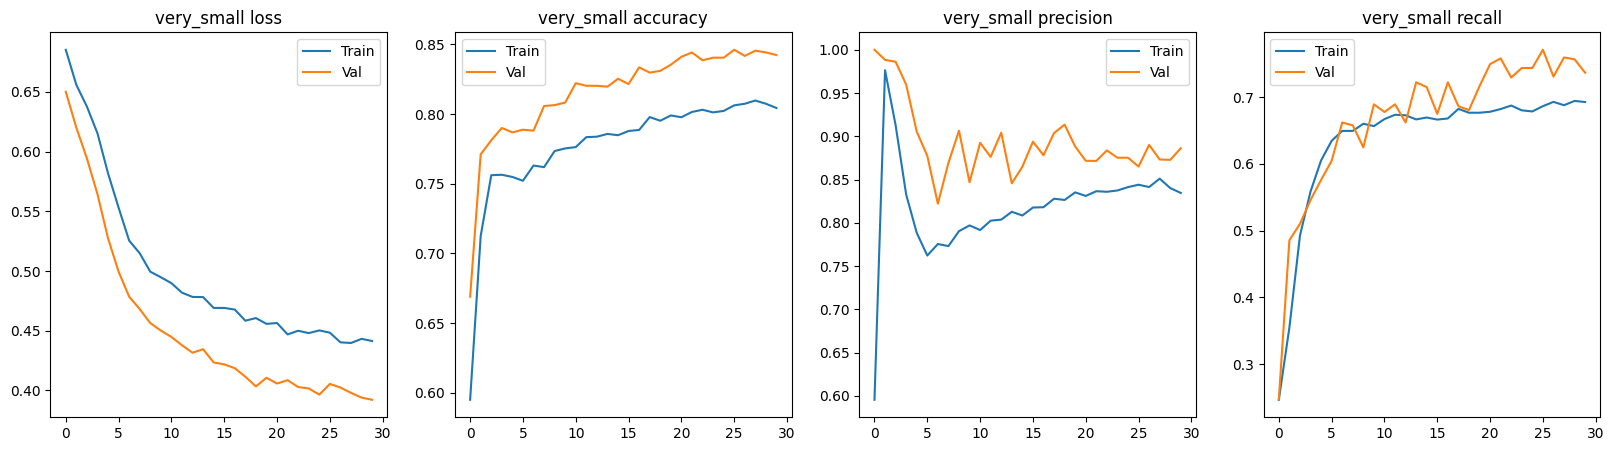


--- TESTING BINARY SMALL ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6401 - loss: 0.6431 - precision: 0.6959 - recall: 0.3225 - val_accuracy: 0.7484 - val_loss: 0.5361 - val_precision: 0.7103 - val_recall: 0.7235 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7679 - loss: 0.5058 - precision: 0.7938 - recall: 0.6381 - val_accuracy: 0.7011 - val_loss: 0.6320 - val_precision: 0.6181 - val_recall: 0.8395 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7857 - loss: 0.4739 - precision: 0.8263 - recall: 0.6491 - val_accuracy: 0.6929 - val_loss: 0.6669 - val_precision: 0.6080 - val_recall: 0.8510 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7948 - loss: 0.4608 - precision: 0.8348 - recall: 0.6651 - val_accuracy: 0.6835 - val_loss: 0.7391 - val_precision: 0.5982 - val_recall: 0.8553 - learning_rate: 5.0000e-05
Epoch 5/30
298

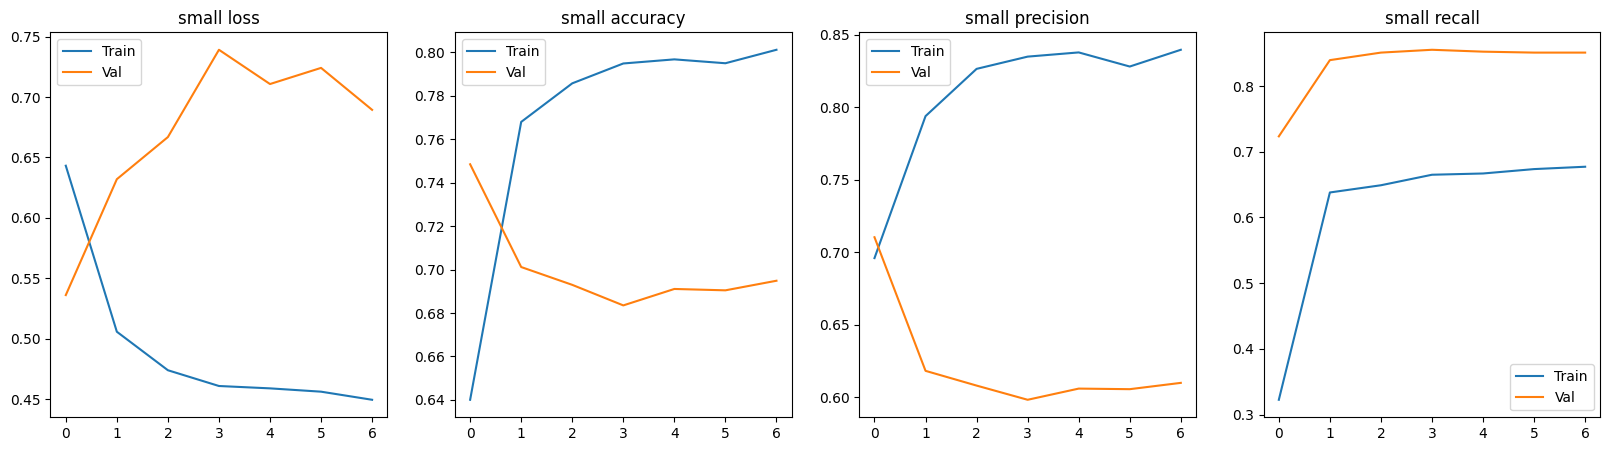


--- TESTING BINARY MEDIUM ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6617 - loss: 0.6298 - precision: 0.7238 - recall: 0.3731 - val_accuracy: 0.4691 - val_loss: 0.8594 - val_precision: 0.4527 - val_recall: 0.9871 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7804 - loss: 0.4815 - precision: 0.8057 - recall: 0.6598 - val_accuracy: 0.5889 - val_loss: 1.2725 - val_precision: 0.5176 - val_recall: 0.9685 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8012 - loss: 0.4450 - precision: 0.8352 - recall: 0.6828 - val_accuracy: 0.5195 - val_loss: 1.6463 - val_precision: 0.4777 - val_recall: 0.9828 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8128 - loss: 0.4352 - precision: 0.8407 - recall: 0.7086 - val_accuracy: 0.4987 - val_loss: 1.7989 - val_precision: 0.4671 - val_recall: 0.9857 - learning_rate: 5.0000e-05
Epoch 5/30
29

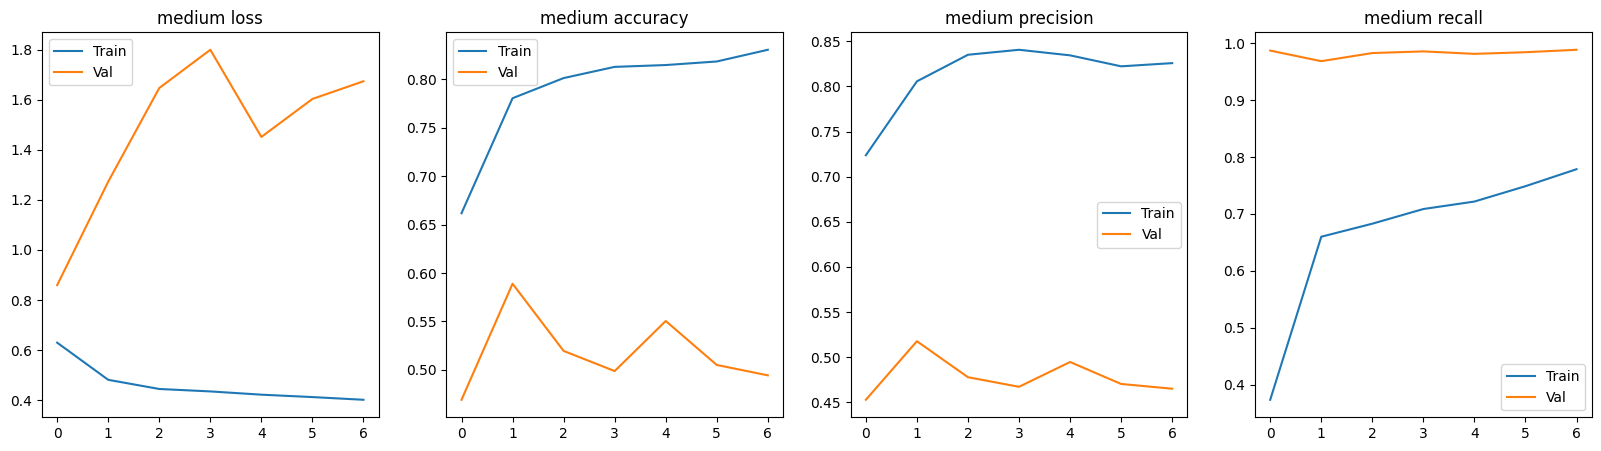


--- TESTING BINARY LARGE ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.7041 - loss: 0.5730 - precision: 0.7920 - recall: 0.4439 - val_accuracy: 0.7049 - val_loss: 0.6332 - val_precision: 0.6186 - val_recall: 0.8596 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7995 - loss: 0.4529 - precision: 0.8374 - recall: 0.6753 - val_accuracy: 0.7692 - val_loss: 0.5179 - val_precision: 0.7000 - val_recall: 0.8324 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8051 - loss: 0.4399 - precision: 0.8507 - recall: 0.6753 - val_accuracy: 0.7636 - val_loss: 0.5562 - val_precision: 0.6724 - val_recall: 0.9026 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.8264 - loss: 0.3999 - precision: 0.8443 - recall: 0.7422 - val_accuracy: 0.8209 - val_loss: 0.4359 - val_precision: 0.7305 - val_recall: 0.9398 - learning_rate: 5.0000e-05
Epoch 5/30

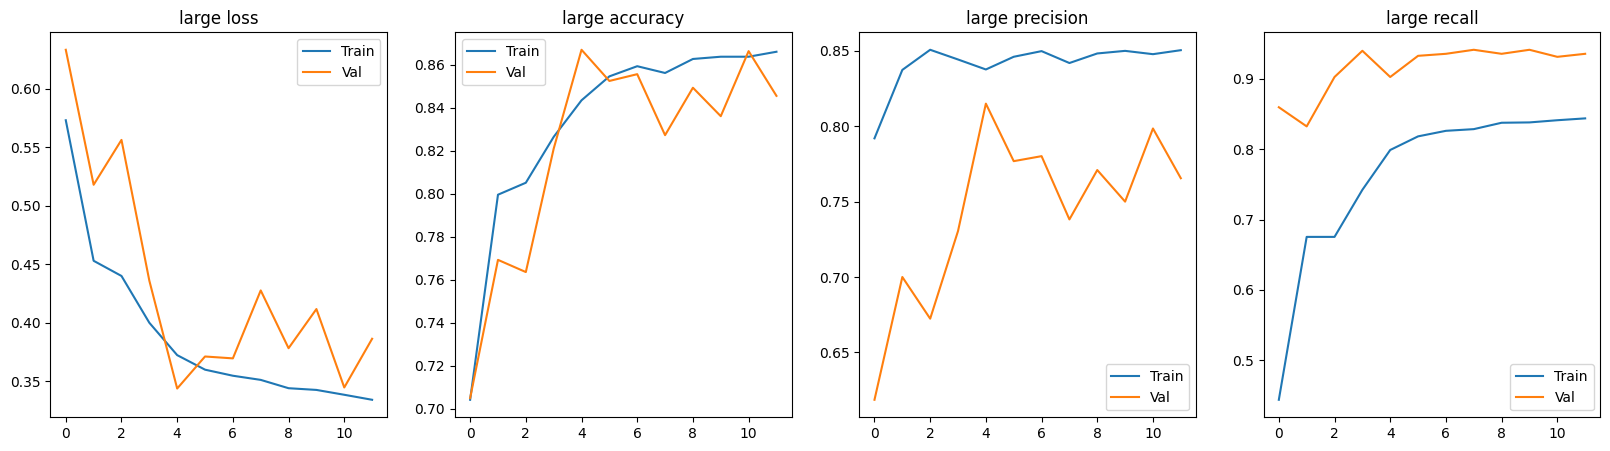


--- TESTING BINARY VERY_LARGE ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 58s 189ms/step - accuracy: 0.7349 - loss: 0.5232 - precision: 0.7799 - recall: 0.5535 - val_accuracy: 0.7547 - val_loss: 0.5520 - val_precision: 0.6703 - val_recall: 0.8711 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8207 - loss: 0.4039 - precision: 0.8207 - recall: 0.7578 - val_accuracy: 0.7705 - val_loss: 0.4587 - val_precision: 0.6680 - val_recall: 0.9513 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8540 - loss: 0.3500 - precision: 0.8354 - recall: 0.8318 - val_accuracy: 0.8739 - val_loss: 0.2992 - val_precision: 0.8097 - val_recall: 0.9327 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 59s 197ms/step - accuracy: 0.8705 - loss: 0.3299 - precision: 0.8506 - recall: 0.8557 - val_accuracy: 0.8165 - val_loss: 0.3918 - val_precision: 0.7224 - val_recall: 0.9470 - learning_rate: 1.0000e-04
E

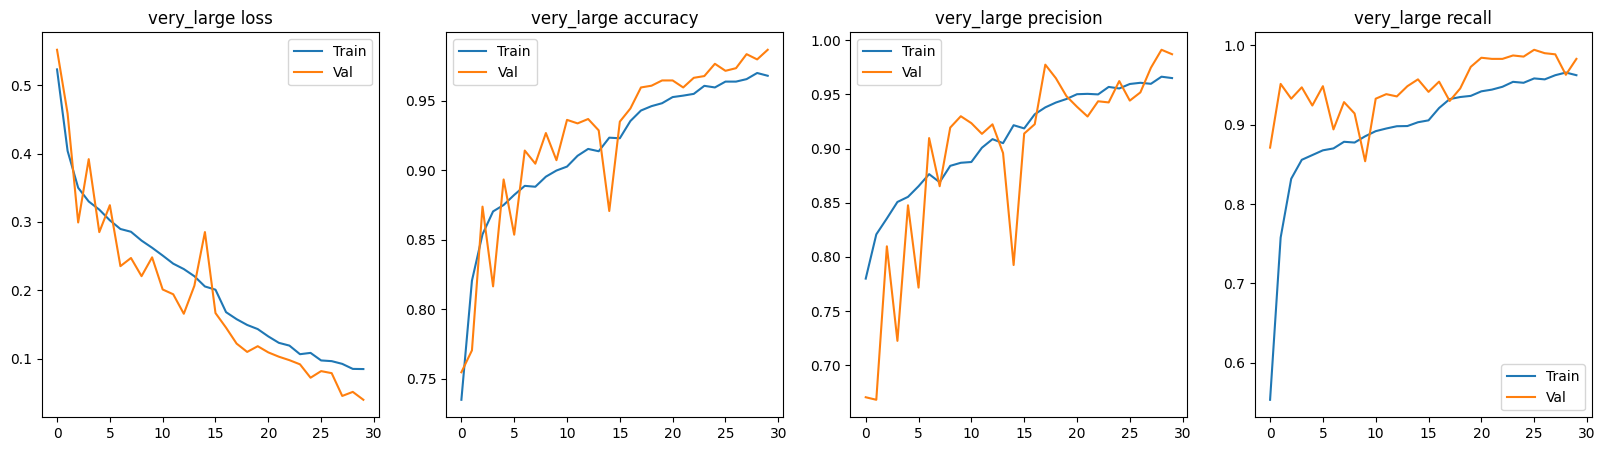

In [26]:
# Assuming you are using binary_focal_loss or standard binary_crossentropy
my_loss = 'binary_crossentropy' 
my_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

all_results = {}
# Test small vs your current medium vs a large version
for model_size in ['very_small','small', 'medium', 'large','very_large']:
    all_results[model_size] = run_binary_experiment(model_size, my_loss, class_weights, my_callbacks)

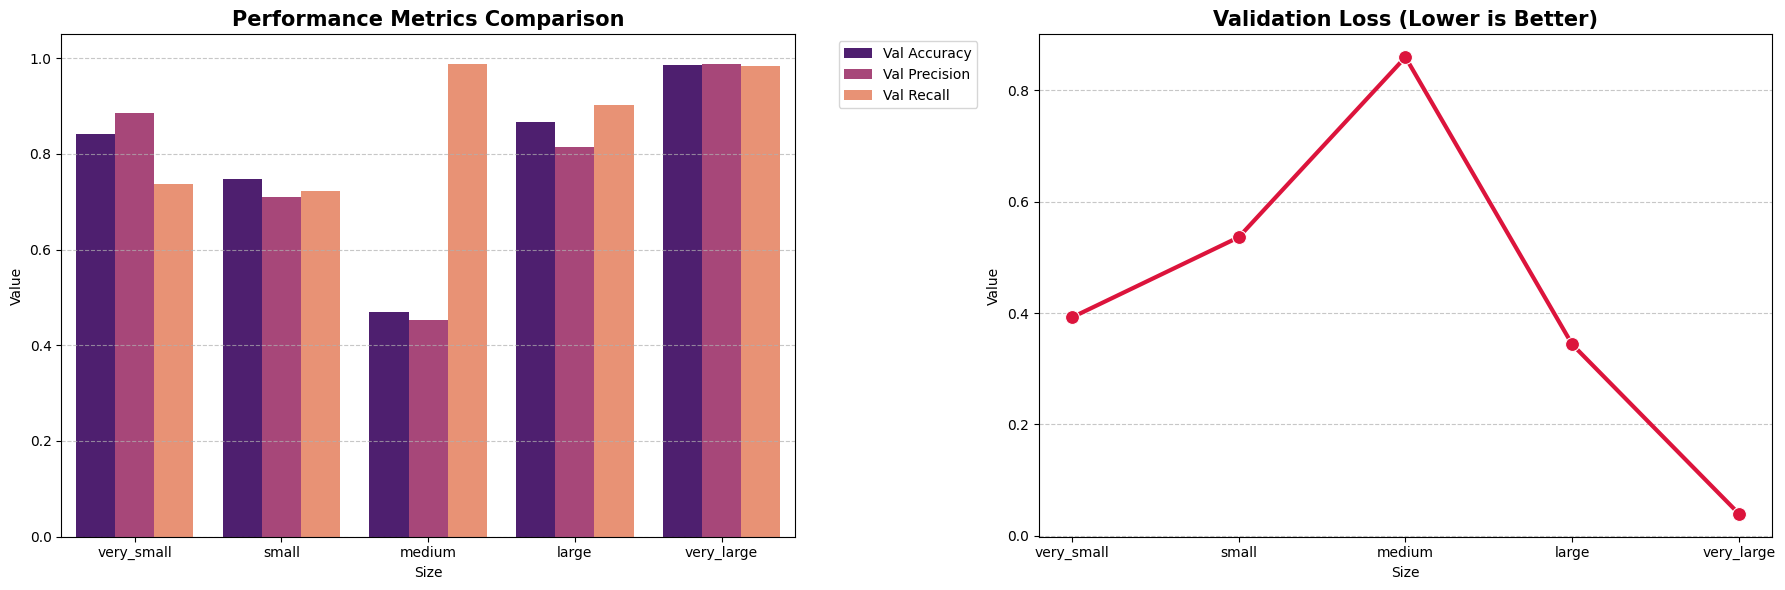

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(results_dict):
    data = []
    for size, result in results_dict.items():
        # Handle the case where the function returned (model, history)
        if isinstance(result, tuple):
            history_obj = result[1]
        else:
            history_obj = result
            
        # Get the index of the best val_loss (best model)
        # Check if the history object is actually the Keras History or just the dict
        h_dict = history_obj.history if hasattr(history_obj, 'history') else history_obj
        
        best_epoch = np.argmin(h_dict['val_loss'])
        
        row = {
            'Size': size,
            'Val Accuracy': h_dict['val_accuracy'][best_epoch],
            'Val Loss': h_dict['val_loss'][best_epoch],
        }
        
        # Add precision/recall if they exist (for Binary)
        if 'val_precision' in h_dict:
            row['Val Precision'] = h_dict['val_precision'][best_epoch]
        if 'val_recall' in h_dict:
            row['Val Recall'] = h_dict['val_recall'][best_epoch]
            
        data.append(row)

    df = pd.DataFrame(data)
    
    # Define the order for the X-axis
    order = ['very_small', 'small', 'medium', 'large', 'very_large']
    # Filter order to only include sizes actually present in the results
    actual_order = [s for s in order if s in df['Size'].values]
    df['Size'] = pd.Categorical(df['Size'], categories=actual_order, ordered=True)
    df = df.sort_values('Size')

    # Create the "Pretty" Plot
    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    df_metrics = df_melted[df_melted['Metric'] != 'Val Loss']
    df_loss = df_melted[df_melted['Metric'] == 'Val Loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Left Plot: Accuracy/Precision/Recall
    sns.barplot(data=df_metrics, x='Size', y='Value', hue='Metric', ax=ax1, palette='magma')
    ax1.set_title('Performance Metrics Comparison', fontsize=15, fontweight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Right Plot: Loss (Lower is better)
    sns.lineplot(data=df_loss, x='Size', y='Value', marker='o', ax=ax2, color='crimson', linewidth=3, markersize=10)
    ax2.set_title('Validation Loss (Lower is Better)', fontsize=15, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
plot_model_comparison(all_results)